## Assignment 1: Customer Feedback Insights
### Task: Extract sentiment and key themes from customer feedback to identify common pain points.

Steps:
- Use a pre-existing dataset (e.g., Amazon Reviews or Trustpilot data from Kaggle).
- Perform basic text preprocessing (lowercasing, stopword removal, tokenization).
- Apply sentiment analysis using a pre-trained model (e.g., Vader, TextBlob, or Hugging Face’s DistilBERT).
- Identify key topics/themes using TF-IDF or Latent Dirichlet Allocation (LDA).
- Generate a simple dashboard (Streamlit/Gradio) to visualize insights.

Success Criteria:
- The system correctly classifies positive vs. negative feedback.
- Outputs 3-5 key themes from reviews.

For this task I will use Amazon Reviews dataset from Kaggle:

https://www.kaggle.com/datasets/tarkkaanko/amazon

To begin with, let's import all the necessary libraries.

In [66]:
import pandas as pd
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import torch
import torch.nn.functional as F
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import warnings
import spacy
import seaborn as sns
import numpy as np

warnings.filterwarnings('ignore')

Import the data

In [3]:
df = pd.read_csv('../data/amazon_reviews.csv', sep=',')

Inspect the data

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,4915.0,NaN,NaN,NaN,2457.0,1418.982617,0.0,1228.5,2457.0,3685.5,4914.0
reviewerName,4914,4594,Amazon Customer,121,NaN,NaN,NaN,NaN,NaN,NaN,NaN
overall,4915.0,NaN,NaN,NaN,4.587589,0.996845,1.0,5.0,5.0,5.0,5.0
reviewText,4914,4912,Works fine my Virgin Mobile HTC EVO V. The pho...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reviewTime,4915,690,2013-12-30,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_diff,4915.0,NaN,NaN,NaN,437.36704,209.439871,1.0,281.0,431.0,601.0,1064.0
helpful_yes,4915.0,NaN,NaN,NaN,1.311089,41.619161,0.0,0.0,0.0,0.0,1952.0
helpful_no,4915.0,NaN,NaN,NaN,0.210376,4.023296,0.0,0.0,0.0,0.0,183.0
total_vote,4915.0,NaN,NaN,NaN,1.521465,44.123095,0.0,0.0,0.0,0.0,2020.0
score_pos_neg_diff,4915.0,NaN,NaN,NaN,1.100712,39.367949,-130.0,0.0,0.0,0.0,1884.0


We can see that there is one row that has N/A values. Let's drop it.

In [79]:
df.dropna(inplace=True)

### We can see that there are a bunch of columns that are not relevant. Let's keep only the reviewText and overall (rating) columns.


In [6]:
df = df[["reviewText", "overall"]]

Also, let's rename them for clarity.

In [7]:
df.rename(columns={"reviewText": "review", "overall": "rating"}, inplace=True)

df.head(5)

,review,rating
0,No issues.,4.0
1,"Purchased this for my device, it worked as adv...",5.0
2,it works as expected. I should have sprung for...,4.0
3,This think has worked out great.Had a diff. br...,5.0
4,"Bought it with Retail Packaging, arrived legit...",5.0


### Since the rating range is between 1-5 with no fractional values, we can consider ratings 1-2 as negative sentiment, 3 as neutral and 4-5 as positive sentiment.

One model that can analyse sentiment into 3 categories is **'roBERTa-base-sentiment'**. Let's use it here.

Later, we will also use a DistilBERT, which will analyse sentiment into 2 categories: positive and negative.

In [9]:
checkpoint = 'cardiffnlp/twitter-roberta-base-sentiment-latest'

Since we are using a pre-trained model, we need to use the same tokenizer as the model was trained with. Let's load it.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
model.eval()

### An efficient way to predict sentiments is to do it in batches. That is because calling the model for each row individually is very inefficient and time-consuming.

Let's define a function that will do it for us.

In [80]:
batch_size = 16

In [ ]:
def predict_sentiments(reviews):
    """
    Returns list (predicted_label, confidence_score) for each review.
    """
    all_predictions = []
    labels = ['negative', 'neutral', 'positive']

    for i in range(0, len(reviews), batch_size):
        batch = reviews[i:i + batch_size]
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512
        )

        with torch.no_grad():
            outputs = model(**inputs)
            probs = F.softmax(outputs.logits, dim=-1)
            preds = torch.argmax(probs, dim=1)

        # Since we used batches - we need to iterate through each prediction in the batch
        for j in range(len(batch)):
            label = labels[preds[j]]
            confidence = probs[j][preds[j]].item()
            all_predictions.append((label, confidence))

    return all_predictions

#### Steps:
1. Tokenize a list of N reviews,
2. Model processes them,
3. Receive logits - output scores for each class (negative, neutral, positive),
4. Normalize them using softmax so that they sum up to 1 and are in range [0, 1],
5. For each review pick highest-scored class and the normalized score,
6. Add the predicted classes, normalized (confidence) scores and that's how the batch.

In [ ]:
%time

all_predictions = []

for i in tqdm(range(0, len(df), batch_size)):
    reviews_batch = df['review'].iloc[i : i + batch_size].to_list()
    predictions = predict_sentiments(reviews_batch)
    all_predictions.extend(predictions)

In [24]:
df_copy = df.copy()
df['sentiment'], df['confidence'] = zip(*all_predictions)

In [25]:
df_copy.head(5)

,review,rating,sentiment,confidence
0,No issues.,4.0,neutral,0.623615
1,"Purchased this for my device, it worked as adv...",5.0,positive,0.906580
2,it works as expected. I should have sprung for...,4.0,neutral,0.521455
3,This think has worked out great.Had a diff. br...,5.0,positive,0.934475
4,"Bought it with Retail Packaging, arrived legit...",5.0,positive,0.887852


### Now that we have successfully applied the sentiment prediction, let's divide the datasets into 3 parts: negative, neutral and positive.

This way, we can see how many reviews are in each category, plot them and also use them for further analysis.

In [26]:
df_negative = df[df["sentiment"] == "negative"]
df_neutral = df[df["sentiment"] == "neutral"]
df_positive = df[df["sentiment"] == "positive"]

In [27]:
df_neutral.head()

,review,rating,sentiment,confidence
0,No issues.,4.0,neutral,0.623615
2,it works as expected. I should have sprung for...,4.0,neutral,0.521455
5,It's mini storage. It doesn't do anything els...,5.0,neutral,0.602260
11,"It works, but file writes are a bit slower tha...",3.0,neutral,0.695182
19,This works with the NL1520. No video stutteri...,5.0,neutral,0.557668


### Let's now plot the distribution of sentiments in the dataset according to the ratings.

In [96]:
def plot_sentiment_spread(df, title="Sentiment Ranking Spread"):
    rating_counts = df['rating'].value_counts()
    rating_counts.sort_index(inplace=True, ascending=False)
    rating_counts.plot(
        title=title,
        kind='bar',
        cmap='viridis',
        xlabel='Rating',
        ylabel='Count',
    )
    plt.show()

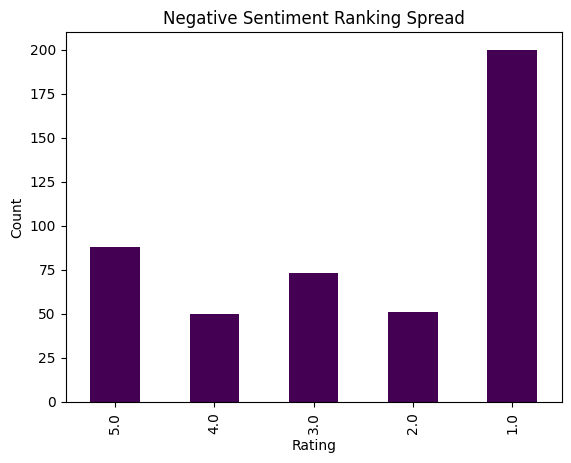

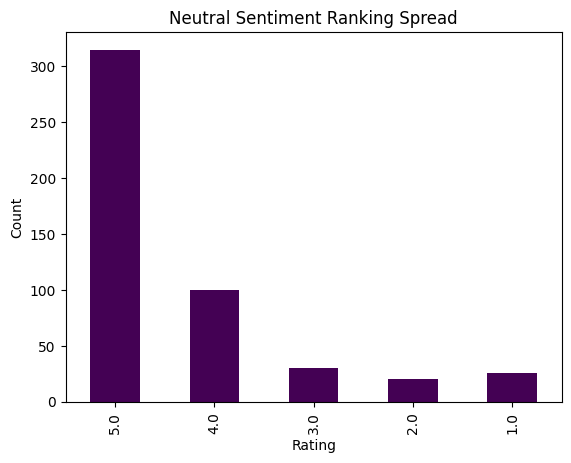

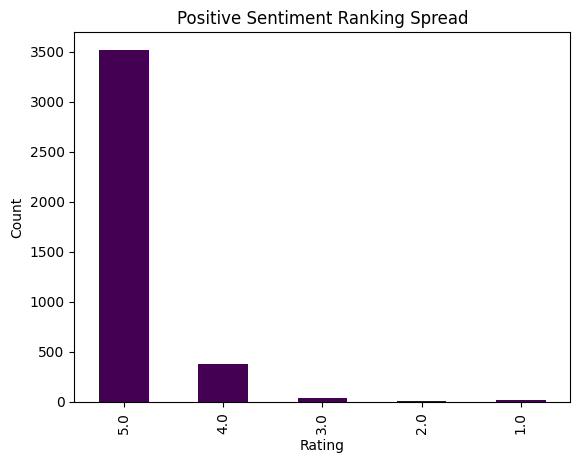

In [97]:
plot_sentiment_spread(df_negative, title="Negative Sentiment Ranking Spread")
plot_sentiment_spread(df_neutral, title="Neutral Sentiment Ranking Spread")
plot_sentiment_spread(df_positive, title="Positive Sentiment Ranking Spread")

We can see that:
- Negative, positive sentiments are quite scattered all around. Why this is the case, it will be shown at the end of this notebook.
- Positive sentiment is the most common in the 5.0 and 4.0 ratings.

### Let's take a look at another graph - the distribution of True vs Predicted count of sentiments.

In [62]:
positive_true_count = df[df['rating'] > 3].shape[0]
neutral_true_count = df[df['rating'] == 3].shape[0]
negative_true_count = df[df['rating'] < 3].shape[0]

positive_count = df_positive['rating'].count()
neutral_count = df_neutral['rating'].count()
negative_count = df_negative['rating'].count()

In [ ]:
def plot_sentiment_comparison(actual, predicted, labels):
    x = np.arange(len(labels))
    width = 0.35
    _, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, actual, width, label='Actual', color='skyblue')
    ax.bar(x + width/2, predicted, width, label='Predicted', color='orange')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Review Count')
    ax.set_title('Actual vs Predicted Sentiment')
    ax.legend()
    plt.tight_layout()
    plt.show()

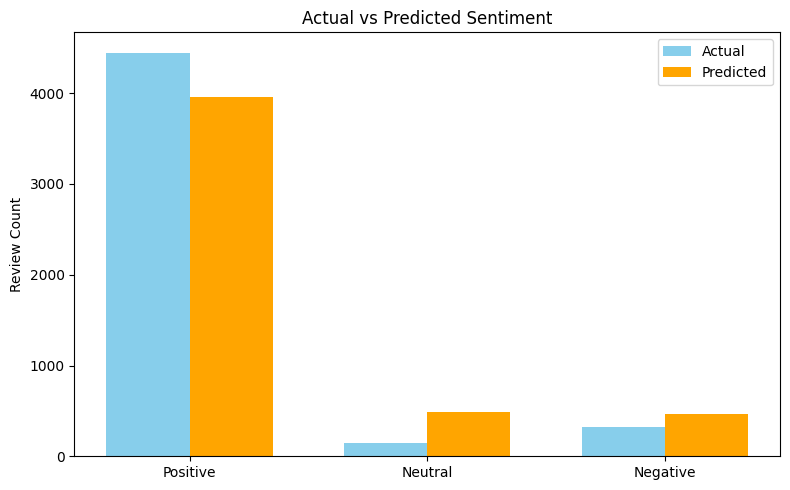

In [91]:
plot_sentiment_comparison(
    [positive_true_count, neutral_true_count, negative_true_count], 
    [positive_count, neutral_count, negative_count], 
    ['Positive', 'Neutral', 'Negative']
)


We can see that the model misclassified some positive reviews as neutral or negative. 

Since this repeats with the DistilBERT model, it will be explained at the end.

### Let's extract the key topics using TF-IDF vectorizer and use 'spacy' library for part-of-speech tagging for finding adjectives and adverbs to describe the topics.

In [30]:
eng_words = spacy.load("en_core_web_sm")

In [31]:
def extract_key_topics(text, n_topics=5, sentiment='negative'):
    vectorizer = TfidfVectorizer(stop_words='english', max_features=500, ngram_range=(3,3))
    X = vectorizer.fit_transform(text)
    X_mean = X.mean(axis=0).A1
    features = vectorizer.get_feature_names_out()
    sorted_indices = X_mean.argsort()[::-1]

    topics = []
    for idx in sorted_indices:
        phrase = features[idx]
        doc = eng_words(phrase)

        if any(token.pos_ in ['ADJ', 'ADV'] for token in doc):
            topics.append(phrase)

        if len(topics) >= n_topics:
            break

    return topics


In [32]:
negative_topics = extract_key_topics(df_negative["review"])
neutral_topics = extract_key_topics(df_neutral["review"])
positive_topics = extract_key_topics(df_positive["review"])

print("Negative sentiment key review topics:\n -",
      "\n - ".join(negative_topics), "\n")

print("Positive sentiment key review topics:\n -",
      "\n - ".join(positive_topics), "\n")

print("Neutral sentiment key review topics:\n -",
      "\n - ".join(neutral_topics), "\n")

Negative sentiment key review topics:
 - card worked fine
 - good luck sandisk
 - gopro hero black
 - hero black edition
 - sd card unexpectedly 

Positive sentiment key review topics:
 - card works great
 - read write speeds
 - works just fine
 - works great samsung
 - phone works great 

Neutral sentiment key review topics:
 - card works great
 - works just fine
 - card worked fine
 - hero black edition
 - just recently started 



Here I also attempted to use BERTopic, which yielded better results on negative sentiment, however, provided no positive or neutral topics.

Also, I used LDA, however, it provided very similar results to these.

#### Much of the initial work - sentiment analysis could have been simplified - using Hugging Face library 'transformers' and it's function 'pipeline'.

- Let's use the default parameters for the pipeline, which will use 'DistilBERT' model for sentiment analysis.
- However, there will be only 2 classes: negative and positive.

In [89]:
df_distilbert = df_copy

sentiment_pipeline = pipeline("sentiment-analysis", model='distilbert/distilbert-base-uncased-finetuned-sst-2-english')

result = sentiment_pipeline(
    df['review'].tolist(),
    truncation=True,
    batch_size=16
)

df_distilbert['sentiment'] = [r['label'] for r in result]
df_distilbert['confidence'] = [r['score'] for r in result]

Device set to use cpu


In [ ]:
df_positive_distilbert = df_distilbert[df_distilbert['sentiment'] == 'POSITIVE']
df_negative_distilbert = df_distilbert[df_distilbert['sentiment'] == 'NEGATIVE']

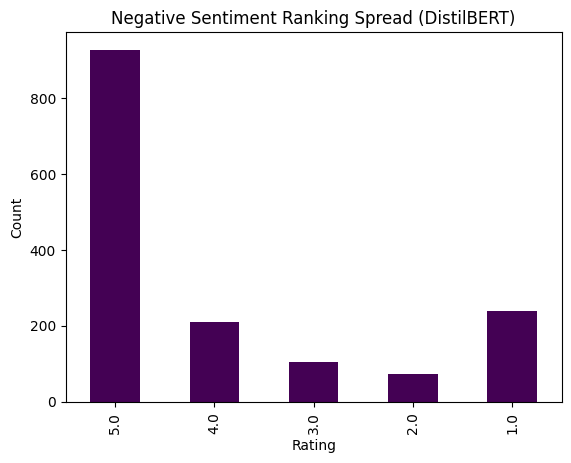

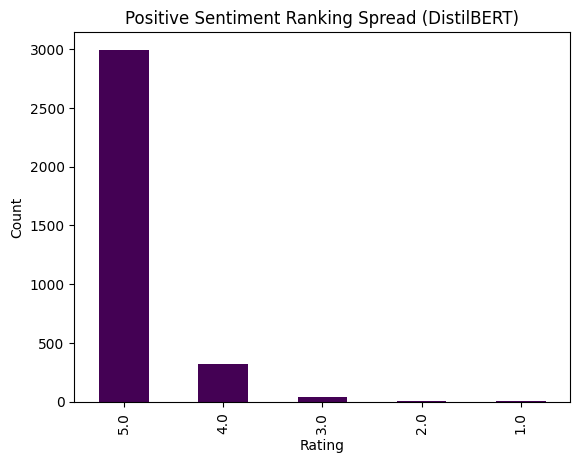

In [98]:
plot_sentiment_spread(df_negative_distilbert, title="Negative Sentiment Ranking Spread (DistilBERT)")
plot_sentiment_spread(df_positive_distilbert, title="Positive Sentiment Ranking Spread (DistilBERT)")

In [76]:
positive_review_count_distilbert = df_distilbert[df_distilbert['sentiment'] == 'POSITIVE'].shape[0]
negative_review_count_distilbert = df_distilbert[df_distilbert['sentiment'] == 'NEGATIVE'].shape[0]

positive_true_count_distilbert = df_distilbert[df_distilbert['rating'] > 3].shape[0]
negative_true_count_distilbert = df_distilbert[df_distilbert['rating'] < 3].shape[0]

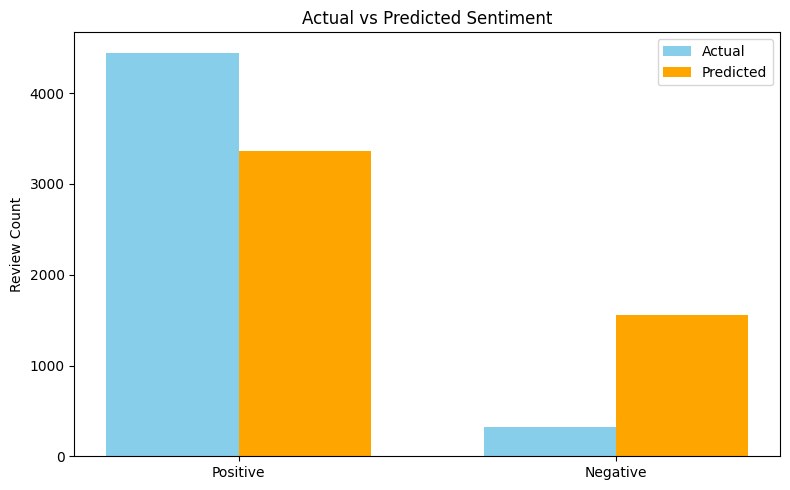

In [78]:
plot_sentiment_comparison(
    [positive_true_count_distilbert, negative_true_count_distilbert],
    [positive_review_count_distilbert, negative_review_count_distilbert],
    ['Positive', 'Negative']
)

In [72]:
negative_topics_distilbert = extract_key_topics(df_negative_distilbert['review'])
positive_topics_distilbert = extract_key_topics(df_positive_distilbert['review'])

In [73]:
print("Negative sentiment key review topics (DistilBERT):\n -",
      "\n - ".join(negative_topics_distilbert), "\n")

print("Positive sentiment key review topics (DistilBERT):\n -",
      "\n - ".join(positive_topics_distilbert), "\n")

Negative sentiment key review topics (DistilBERT):
 - new samsung galaxy
 - gopro hero black
 - card worked fine
 - works great samsung
 - read write speeds 

Positive sentiment key review topics (DistilBERT):
 - card works great
 - works just fine
 - read write speeds
 - phone works great
 - works great fast 



### Let's compare how 2 different approaches for sentiment analysis performed, focusing on rankings and the predicted sentiment.

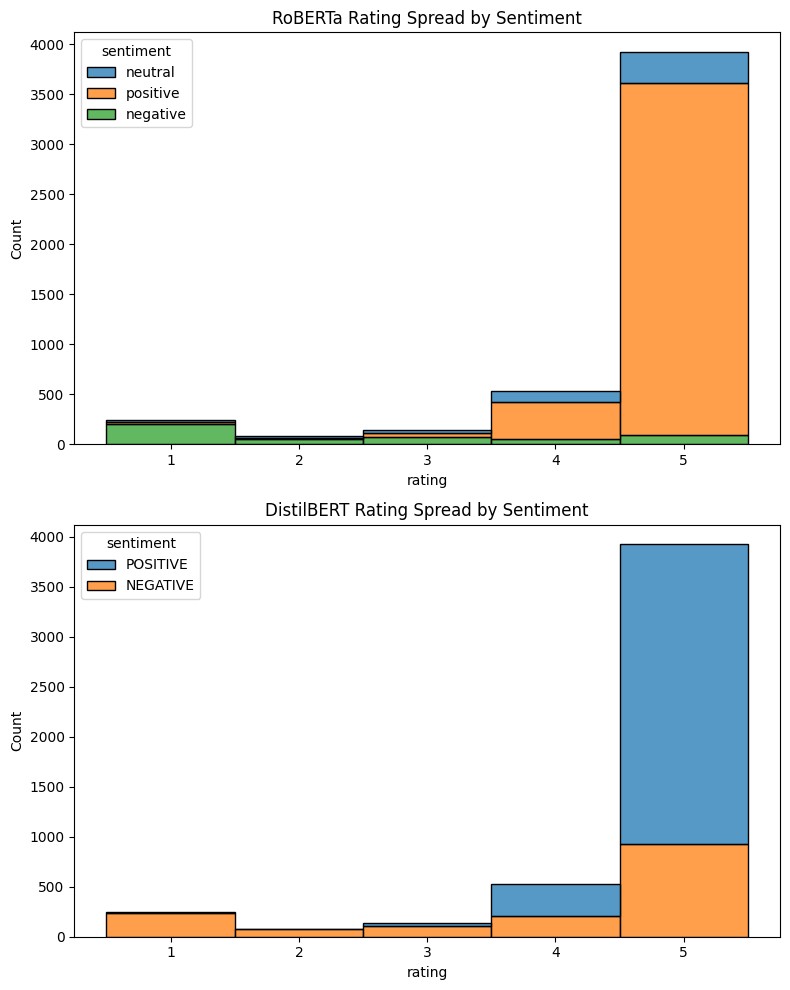

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(8, 10))

sns.histplot(data=df, x='rating', hue='sentiment', discrete=True, multiple='stack', ax=axs[0])
axs[0].set_title("RoBERTa Rating Spread by Sentiment")

sns.histplot(data=df_distilbert, x='rating', hue='sentiment', discrete=True, multiple='stack', ax=axs[1])
axs[1].set_title("DistilBERT Rating Spread by Sentiment")

plt.tight_layout()
plt.show()


In [ ]:
df_compare = df[['review']].copy()
df_compare['sentiment_roberta'] = df['sentiment']
df_compare['sentiment_distilbert'] = df_distilbert['sentiment']

df_compare['match'] = df_compare['sentiment_roberta'].str.upper() == df_compare['sentiment_distilbert']
match_rate = df_compare['match'].mean()

print(f"Match between models: {match_rate * 100:.1f}%")


Match between models: 73.4%


In [ ]:
misclassified_positive = df_distilbert[
    (df_distilbert['rating'] <= 2) & 
    (df_distilbert['sentiment'] == 'POSITIVE')
]

misclassified_positive[["rating", "sentiment", "review"]].head(2)


,rating,sentiment,review
462,1.0,POSITIVE,I really want to like these and I do trust San...
488,1.0,POSITIVE,I had this for my smart phone and it kept dism...


In [ ]:
misclassified_negative = df_distilbert[
    (df_distilbert['rating'] == 5) & 
    (df_distilbert['sentiment'] == 'NEGATIVE')
]

misclassified_negative[["rating", "sentiment", "review"]].head(2)

,rating,sentiment,review
8,5.0,NEGATIVE,Works in a HTC Rezound. Was running short of ...
14,5.0,NEGATIVE,Heard that the card's write speed is insuffici...


### **Conclusions**:
1. **It was common for reviews to be misclassified due to the model's inability to understand the review's context, especially when the review contained a mix of both positive and negative words.**
    
    For example:
     - Review that was misclassified as positive, but had a rating of 1/5 contained words such as: "like these", "trust", "thank you", "exceptional customer service". 
     - Review that was misclassified as negative, but had a rating of 5/5 contained words such as: "speed is insufficient", "was running short on space".


2. **Even though that DistilBERT had to only classify reviews into 2 classes, it performed worse than the roBERTa model, which had to classify reviews into 3 classes.**
    - After looking into it, I found that:
        - DistilBERT is a model with ~66 million parameters, while roBERTa is a model with ~125 million parameters.
        - DistilBERT has 6 transformer layers, while roBERTa has 12 transformer layers.
    - Overall, DistilBERT is a smaller and faster model, but it sacrifices some accuracy for speed.
    - Therefore, it is not surprising that roBERTa performed better, even though it had to classify reviews into 3 classes.


3. **I attempted to use Latent Dirichlet Allocation (LDA) to extract key topics from the reviews, but it provided similar results to TF-IDF.**

4. **I attempted to use BERTopic for topic extraction, but TF-IDF provided better results.**
    - I think this is because the dataset was too small for BERTopic to work properly. Because after splitting positive, negative and neutral reviews, for example, there were 4000 positive reviews and only 900 rows were left for both negative and neutral reviews.
    - Therefore, BERTopic would work better with a larger dataset, where there are more reviews for each class, because:
        - It uses clustering to group similar reviews together - the more reviews there are, the better the clustering.